In [12]:
import json
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt

In [2]:
json_path = r"C:\Users\leroquan\Documents\Data\meteo\stations meteo\Pully\2023.json"
with open(json_path, 'r') as f:
    json_data = json.load(f)

In [19]:
date_start = np.datetime64("2023-11-04 14:00")
date_end = np.datetime64("2023-11-08 15:00")

In [20]:
json_data

{'time': ['2023-01-01T00:00:00+00:00',
  '2023-01-01T01:00:00+00:00',
  '2023-01-01T02:00:00+00:00',
  '2023-01-01T03:00:00+00:00',
  '2023-01-01T04:00:00+00:00',
  '2023-01-01T05:00:00+00:00',
  '2023-01-01T06:00:00+00:00',
  '2023-01-01T07:00:00+00:00',
  '2023-01-01T08:00:00+00:00',
  '2023-01-01T09:00:00+00:00',
  '2023-01-01T10:00:00+00:00',
  '2023-01-01T11:00:00+00:00',
  '2023-01-01T12:00:00+00:00',
  '2023-01-01T13:00:00+00:00',
  '2023-01-01T14:00:00+00:00',
  '2023-01-01T15:00:00+00:00',
  '2023-01-01T16:00:00+00:00',
  '2023-01-01T17:00:00+00:00',
  '2023-01-01T18:00:00+00:00',
  '2023-01-01T19:00:00+00:00',
  '2023-01-01T20:00:00+00:00',
  '2023-01-01T21:00:00+00:00',
  '2023-01-01T22:00:00+00:00',
  '2023-01-01T23:00:00+00:00',
  '2023-01-02T00:00:00+00:00',
  '2023-01-02T01:00:00+00:00',
  '2023-01-02T02:00:00+00:00',
  '2023-01-02T03:00:00+00:00',
  '2023-01-02T04:00:00+00:00',
  '2023-01-02T05:00:00+00:00',
  '2023-01-02T06:00:00+00:00',
  '2023-01-02T07:00:00+00:00',


In [21]:
# Extract data
times = json_data["time"]
precip_data = json_data["variables"]["precipitation"]["data"]

In [22]:
# Build a list of rows
rows = []
for t, pr in zip(times, precip_data):
    dt = datetime.fromisoformat(t.replace("Z", "+00:00"))
    rows.append([
        dt,
        pr
    ])

# Create DataFrame
df = pd.DataFrame(rows, columns=["time", "Precipitation"])
df['time'] = df['time'].dt.tz_convert(None)  # removes timezone

In [23]:
df_crop = df[(df['time'] > date_start) & (df['time'] < date_end)]

In [24]:
hours_before_sampling = np.sort(-1*np.array(range(len(df_crop["time"]))))

Text(0, 0.5, 'Precipitation (mm/h)')

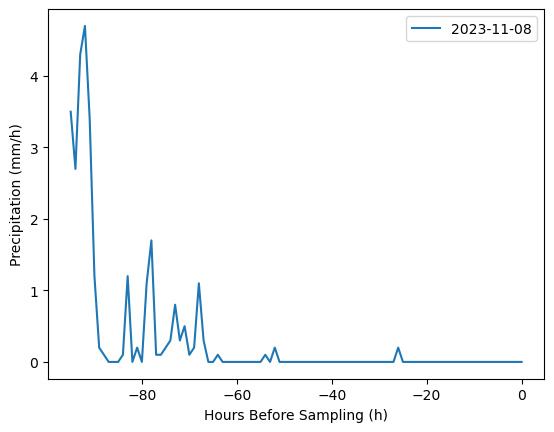

In [25]:
plt.plot(hours_before_sampling, df_crop["Precipitation"], label="2023-11-08")
plt.legend()
plt.xlabel("Hours Before Sampling (h)")
plt.ylabel("Precipitation (mm/h)")